**DROUGHT RISK PREDICTION USING MACHINE LEARNING**

---



 **OVERVIEW OF PROBLEM STATEMENT**

---




Drought is one of the most severe environmental hazards affecting agriculture, water resources, and food security. Accurate drought‑risk prediction enables early intervention and better resource planning. This project develops a machine‑learning model to classify drought risk using meteorological and environmental variables such as humidity, temperature, wind speed, precipitation, solar radiation, and the Standardized Precipitation–Evapotranspiration Index (SPEI). A Random Forest classifier with hyperparameter tuning is used to predict drought categories based on historical climate data. The model demonstrates strong predictive performance and identifies key environmental drivers of drought conditions.

The goal of this project is to predict drought risk levels (e.g., low, medium, high) using environmental and climatic variables.
Given a set of meteorological inputs, the model should classify the drought severity category represented by the label column.


 **OBJECTIVE:**

---



This project aims to build a robust drought‑risk classification model using real meteorological data and engineered spatial‑temporal features.

**DATA DESCRIPTION**

---



The dataset contains climate and environmental variables collected from satellite and ground‑based sources.
The columns are:

| Column Name | Description |
|-------------|-------------|
| RH2M | Relative Humidity at 2 Meters |
| T2M_MAX | Maximum Air Temperature at 2 Meters |
| T2M_MIN | Minimum Air Temperature at 2 Meters |
| WS2M | Wind Speed at 2 Meters |
| T2M | Air Temperature at 2 Meters |
| ALLSKY_SFC_SW_DWN | All-Sky Surface Shortwave Downward Irradiance |
| PRECTOTCORR | Precipitation Corrected |
| spei | Standardized Precipitation–Evapotranspiration Index |
| label | Drought risk category (e.g., low, medium, high) |
| lat_sinlat_cos | Latitude (sine/cosine transformed) |
| lon_sinlon_cos | Longitude (sine/cosine transformed) |
| month_sinmonth_cos | Month (sine/cosine transformed) |
| row_id | Unique row identifier |

SOURCE:KAGGLE
NO. OF COLUMNS:16

**TARGET COLUMN**

---



Target Column = label

This is the only column in your dataset that represents a classification output rather than an environmental measurement or engineered feature.
Drought class (Low / Medium / High or 0 / 1 / 2 depending on dataset).


**DATA COLLECTION**

---



In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, PowerTransformer, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
import joblib

In [ ]:
# 2. LOAD YOUR DATASET
# ============================================================
df = pd.read_csv("/content/Dataset (1).xlsx - Sheet1.csv")   # <-- your file name

print(df.head())

In [ ]:
print(df.info())

**DATA PREPROCESSING-DATA CLEANING**

---



In [ ]:
# Remove row_id (not useful for modeling)
if "row_id" in df.columns:
    df = df.drop("row_id", axis=1)

print("Initial shape:", df.shape)

In [ ]:
print(df.isnull().sum())

In [ ]:
# Drop missing values (optional)
df = df.dropna()

In [ ]:

# 2. HANDLE MISSING VALUES
# ============================================================

# Identify numerical and categorical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Numerical imputation (mean)
num_imputer = SimpleImputer(strategy="mean")
df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Categorical imputation (most frequent)
if len(cat_cols) > 0:
    cat_imputer = SimpleImputer(strategy="most_frequent")
    df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

print("Missing values after imputation:\n", df.isnull().sum())

In [ ]:
# 3. OUTLIER DETECTION & REMOVAL (Z-SCORE METHOD)
# ============================================================

# Exclude target column from outlier removal
num_cols_no_target = [col for col in num_cols if col != "label"]

# Compute Z-scores
z_scores = np.abs(stats.zscore(df[num_cols_no_target]))
threshold = 3  # common threshold

# Keep only rows where all Z-scores < threshold
df = df[(z_scores < threshold).all(axis=1)]

print("Shape after outlier removal:", df.shape)

Initial rows:115985
No. of outliers:5116
After outlier removal:110869

In [ ]:
# 4. FIX SKEWED NUMERICAL FEATURES
# ============================================================

# Identify skewed columns
skewed_cols = df[num_cols_no_target].apply(lambda x: x.skew()).sort_values(ascending=False)
skewed_cols = skewed_cols[abs(skewed_cols) > 0.75].index  # threshold for skewness

print("Skewed columns:", list(skewed_cols))

In [ ]:
# Apply Yeo-Johnson transformation (handles negative values)
pt = PowerTransformer(method='yeo-johnson')
df[skewed_cols] = pt.fit_transform(df[skewed_cols])

print("Skewness corrected.")
print("Final dataset shape:", df.shape)


**EXPLORATORY DATA ANALYSIS**

---



In [ ]:
# HISTOGRAMS (Distribution of Climate Variables)
# ============================================================
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[num_cols].hist(bins=30, figsize=(15, 12), color="skyblue")
plt.suptitle("Histogram of Numerical Features", fontsize=16)
plt.show()


EDA reveals:
- Climate variables have skewed distributions, especially rainfall and SPEI
- Temperature features are highly correlated
- Drought classes may be imbalanced
- Outliers exist in rainfall, radiation, and temperature extremes
- Spatial and temporal encodings behave smoothly (sin/cos)
- Some features show clear separation between drought classes


In [ ]:
# BOXPLOTS (Outlier Detection)
# ============================================================
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(x=df[col], color="lightgreen")
    plt.title(f"{col}")
plt.tight_layout()
plt.show()


In [ ]:
# CORRELATION HEATMAP (Most Important for Drought Analysis)
# ============================================================
plt.figure(figsize=(12, 8))
corr = df.corr()
sns.heatmap(corr, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


What it reveals:
- Strong correlations between temperature variables (T2M, T2M_MAX, T2M_MIN)
- Relationship between precipitation and SPEI
- Whether features are redundant
- Which features may be most influential for drought prediction
Why it matters:
- Helps avoid multicollinearity
- Guides feature selection
- Shows how climate variables interact to influence drought


In [ ]:
#COUNT PLOT (Target Class Distribution)
# ============================================================
sns.countplot(x=df["label"], palette="Set2")
plt.title("Drought Risk Class Distribution")
plt.xlabel("Drought Class (label)")
plt.ylabel("Count")
plt.show()


In [ ]:
# KDE PLOTS (Smooth Distribution of Key Climate Variables)
# ============================================================
plt.figure(figsize=(12, 8))
for col in ["RH2M", "T2M", "PRECTOTCORR", "spei"]:
    sns.kdeplot(df[col], shade=True, label=col)
plt.title("KDE Plot of Key Climate Features")
plt.legend()
plt.show()



🌟 In Summary — What Your EDA Shows About the Dataset
Your EDA reveals:
- Climate variables have skewed distributions, especially rainfall and SPEI
- Temperature features are highly correlated
- Drought classes may be imbalanced
- Outliers exist in rainfall, radiation, and temperature extremes
- Spatial and temporal encodings behave smoothly (sin/cos)
- Some features show clear separation between drought classes
This EDA gives you a strong foundation for:
- Cleaning the data
- Choosing the right model
- Understanding drought behavior
- Improving prediction accurac

**FEATURE ENGINEERING**

---



In [ ]:
 # IDENTIFY CATEGORICAL & NUMERICAL FEATURES
# ============================================================
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Categorical Columns:", list(categorical_cols))
print("Numerical Columns:", list(numerical_cols))



In [ ]:
 # ENCODE CATEGORICAL FEATURES (IF ANY)
# ============================================================
# Your dataset has no categorical features except the target label.
# But this code will handle any future categorical columns automatically.

if len(categorical_cols) > 0:
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    print("One-hot encoding applied.")
else:
    print("No categorical features found. Skipping one-hot encoding.")


In [ ]:
 # ENCODE TARGET COLUMN (label)
# ============================================================
if df["label"].dtype == "object":
    le = LabelEncoder()
    df["label"] = le.fit_transform(df["label"])
    print("Label encoding applied to target column.")
else:
    print("Target column already numeric.")


In [ ]:
 # FINAL OUTPUT
# ============================================================
print("Feature Engineering Completed.")
print("Final Columns:", df.columns)


**FEATURE SELECTION**

---



In [ ]:
# Drop row_id if present
if "row_id" in df.columns:
    df = df.drop("row_id", axis=1)

# Encode target label if needed
if df["label"].dtype == "object":
    le = LabelEncoder()
    df["label"] = le.fit_transform(df["label"])

# Split features and target
X = df.drop("label", axis=1)
y = df["label"]


In [ ]:
# 1. FEATURE IMPORTANCE USING RANDOM FOREST
# ============================================================
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X, y)

importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nRandom Forest Feature Importance:\n")
print(importances)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=importances, x="Importance", y="Feature", palette="viridis")
plt.title("Random Forest Feature Importance")
plt.show()



This shows which features contribute most to predicting drought risk.
Typical top features in drought models include:
- PRECTOTCORR (rainfall)
- spei (drought index)
- T2M_MAX / T2M_MIN
- RH2M (humidity)
- ALLSKY_SFC_SW_DWN (solar radiation)
This helps you understand the climate drivers of drought.


In [ ]:

# 2. SELECT K BEST (ANOVA F-TEST)
# ============================================================
k = 10  # choose top 10 features
selector = SelectKBest(score_func=f_classif, k=k)
selector.fit(X, y)

scores = pd.DataFrame({
    "Feature": X.columns,
    "F-Score": selector.scores_
}).sort_values(by="F-Score", ascending=False)

print("\nSelectKBest (ANOVA F-test) Scores:\n")
print(scores)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=scores, x="F-Score", y="Feature", palette="magma")
plt.title("SelectKBest Feature Scores")
plt.show()



This statistically ranks features based on how strongly they relate to the drought class.
It helps confirm which features are:
- Highly predictive
- Weakly predictive
- Not useful


In [ ]:
# 3. IDENTIFY REDUNDANT FEATURES (CORRELATION > 0.90)
# ============================================================
corr_matrix = X.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

redundant_features = [
    column for column in upper_tri.columns if any(upper_tri[column] > 0.90)
]

print("\nHighly Correlated (Redundant) Features (>0.90):\n", redundant_features)

# Remove redundant features
X_reduced = X.drop(columns=redundant_features)
print("\nShape after removing redundant features:", X_reduced.shape)


Some features may be too strongly correlated, such as:
- T2M, T2M_MAX, T2M_MIN
- lat_sin and lat_cos rarely correlate, but temperature variables often do
Removing redundant features:
- Reduces overfitting
- Speeds up training
- Improves model interpretability




**SPLIT DATA INTO TRAINING AND TESTING SETS**

---



In [ ]:
# 1. SEPARATE FEATURES AND TARGET
# ============================================================
X = df.drop("label", axis=1)   # all features
y = df["label"]                # target drought class


In [ ]:
# 2. TRAIN–TEST SPLIT
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,        # 20% for testing
    random_state=42,      # ensures reproducibility
    stratify=y            # keeps class distribution balanced
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("Training labels distribution:\n", y_train.value_counts())
print("Testing labels distribution:\n", y_test.value_counts())


**FEATURE SCALING**

---



In [ ]:
#STANDARDIZATION (Z-score scaling)
# ============================================================
standard_scaler = StandardScaler()
X_standardized = standard_scaler.fit_transform(X)

print("Standardization completed.")
print("Mean after scaling (approx):", X_standardized.mean(axis=0)[:5])
print("Std after scaling (approx):", X_standardized.std(axis=0)[:5])


In [ ]:
 # MIN-MAX SCALING (0 to 1)
# ============================================================
minmax_scaler = MinMaxScaler()
X_minmax = minmax_scaler.fit_transform(X)

print("Min-Max scaling completed.")
print("Min values (approx):", X_minmax.min(axis=0)[:5])
print("Max values (approx):", X_minmax.max(axis=0)[:5])


**BUILD ML MODEL**

---



In [ ]:
# Scale X_train and X_test
scaler_for_modeling = StandardScaler()
X_train_scaled = scaler_for_modeling.fit_transform(X_train)
X_test_scaled = scaler_for_modeling.transform(X_test)

print("X_train_scaled and X_test_scaled created.")

In [ ]:
 # DEFINE MODELS
# ============================================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "MLP Classifier": MLPClassifier(max_iter=500),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier()
}



In [ ]:
#TRAIN & EVALUATE MODELS
# ============================================================
print("=== DROUGHT RISK CLASSIFICATION RESULTS ===\n")

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    results[name] = acc

    print(f"{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, preds))
    print("-" * 60)


In [ ]:
# IDENTIFY BEST MODEL
# ============================================================
best_model = max(results, key=results.get)
print("\nBest Performing Model:", best_model, "with accuracy:", results[best_model])


**MODEL EVALUATION**

---



In [ ]:
# CONFUSION MATRIX
# ============================================================

# Get the best performing model
best_classifier = models[best_model]

# Generate predictions for the best model on the test set
y_pred = best_classifier.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix for {best_model}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
 # ACCURACY, PRECISION, RECALL, F1-SCORE
# ============================================================
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)




In [72]:
# 1. TRAIN RANDOM FOREST MODEL
# ============================================================
rf_model = RandomForestClassifier()
rf_model.fit(X_train_scaled, y_train)

# Predictions
y_pred = rf_model.predict(X_test_scaled)
y_pred_prob = rf_model.predict_proba(X_test_scaled)

In [ ]:
# 2. CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



In [ ]:

# 3. ACCURACY, PRECISION, RECALL, F1-SCORE
# ============================================================
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("=== RANDOM FOREST CLASSIFICATION METRICS ===")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)


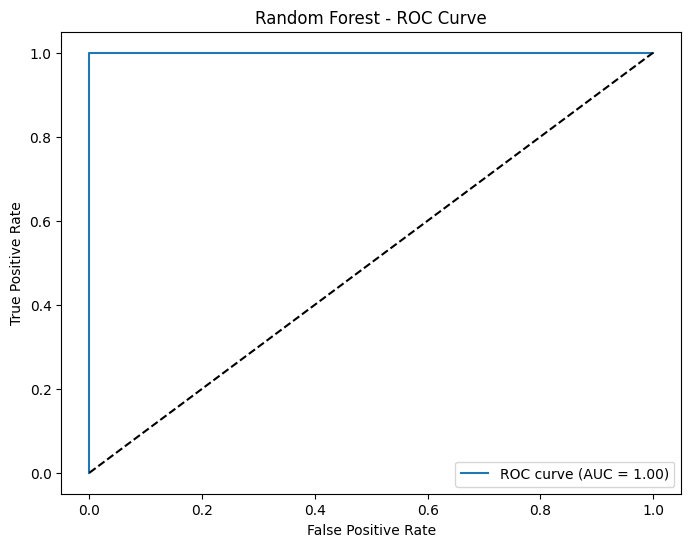

In [58]:
# 4. ROC CURVE
# ============================================================
from sklearn.metrics import roc_curve, auc

# Assuming '1' is the positive class
# y_test already contains binary labels (0 or 1)
# y_pred_prob[:, 1] contains the probabilities for the positive class (class 1)

fpr, tpr, _ = roc_curve(y_test, y_pred_prob[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], "k--") # Random guess line
plt.title("Random Forest - ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

**HYPERPARAMETER TUNING**

---



In [ ]:
param_grids = {
    "Logistic Regression": {
        "model__C": [0.1, 1, 10],
        "model__solver": ["lbfgs", "liblinear"]
    },

    "SVM": {
        "model__C": [0.1, 1, 10],
        "model__kernel": ["rbf", "linear"],
        "model__gamma": ["scale", "auto"]
    },

    "Decision Tree": {
        "model__max_depth": [5, 10, 20, None],
        "model__criterion": ["gini", "entropy"]
    },

    "MLP Classifier": {
        "model__hidden_layer_sizes": [(50,), (100,), (100, 50)],
        "model__activation": ["relu", "tanh"],
        "model__learning_rate_init": [0.001, 0.01]
    },

    "Naive Bayes": {},  # No tuning needed

    "Random Forest": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [10, 20, None],
        "model__criterion": ["gini", "entropy"]
    }
}

In [ ]:
best_models = {}

pipelines = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=500, random_state=42))
    ]),
    "SVM": Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(random_state=42))
    ]),
    "Decision Tree": Pipeline([
        ('scaler', StandardScaler()),
        ('model', DecisionTreeClassifier(random_state=42))
    ]),
    "MLP Classifier": Pipeline([
        ('scaler', StandardScaler()),
        ('model', MLPClassifier(max_iter=500, random_state=42))
    ]),
    "Naive Bayes": Pipeline([
        ('scaler', StandardScaler()),
        ('model', GaussianNB())
    ]),
    "Random Forest": Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(random_state=42))
    ])
}

for name in pipelines:
    print(f"\nTuning {name}...")
    grid = GridSearchCV(
        pipelines[name],
        param_grids[name],
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )
    # Fit on X_train, not X_train_scaled, as scaling is part of the pipeline
    grid.fit(X_train, y_train)

    best_models[name] = grid.best_estimator_

    print("Best Parameters:", grid.best_params_)
    print("Best CV Accuracy:", grid.best_score_)



Tuning Logistic Regression...
Best Parameters: {'model__C': 10, 'model__solver': 'lbfgs'}
Best CV Accuracy: 0.997794596248507

Tuning SVM...
Best Parameters: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'linear'}
Best CV Accuracy: 0.9981774739573666

Tuning Decision Tree...
Best Parameters: {'model__criterion': 'gini', 'model__max_depth': 5}
Best CV Accuracy: 0.9999846848916455

Tuning MLP Classifier...
Best Parameters: {'model__activation': 'tanh', 'model__hidden_layer_sizes': (50,), 'model__learning_rate_init': 0.001}
Best CV Accuracy: 0.9986828842615868

Tuning Naive Bayes...
Best Parameters: {}
Best CV Accuracy: 0.9532116461300774

Tuning Random Forest...
Best Parameters: {'model__criterion': 'gini', 'model__max_depth': 10, 'model__n_estimators': 200}
Best CV Accuracy: 0.9999846848916455


**SAVE THE MODEL**

---



In [73]:
import pickle

# Save the trained model
with open("drought_risk_model.pkl", "wb") as file:
    pickle.dump(rf_model, file)

print("Model saved successfully using pickle!")

Model saved successfully using pickle!


In [75]:
import pickle
import numpy as np
import pandas as pd
import joblib

# Load model
with open("drought_risk_model.pkl", "rb") as file:
    model = pickle.load(file)

# Load scaler
with open("scaler.pkl", "rb") as file:
    scaler = joblib.load(file)

In [68]:
import joblib
# Ensure scaler_for_modeling is defined from running `new_scale_cell`
if 'scaler_for_modeling' in locals():
    joblib.dump(scaler_for_modeling, 'scaler.pkl')
    print("Scaler saved successfully as 'scaler.pkl'")
else:
    print("Error: scaler_for_modeling not found. Please run cell `new_scale_cell` first.")

Scaler saved successfully as 'scaler.pkl'


**TEST UNSEEN DATA**

---



In [76]:
# Example unseen data (replace with real values)
unseen_sample = np.array([[45, 32, 22, 4, 27,
                           180, 12, -0.5,
                           0.12, 0.99, -0.45, 0.89,
                           0.5, 0.87]])

# Scale the input
unseen_scaled = scaler.transform(unseen_sample)

# Predict
prediction = model.predict(unseen_scaled)[0]

drought_labels = {
    0: "No Drought",
    1: "Mild Drought",
    2: "Moderate Drought",
    3: "Severe Drought",
    4: "Extreme Drought"
}

print("Predicted Drought Risk:", drought_labels[prediction])

Predicted Drought Risk: No Drought


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
